In [ ]:
"""
import necessary libraries
"""
import pandas as pd
import s3fs

# Configuration de la connexion
S3_ENDPOINT = "http://localhost:9000"
S3_KEY = "admin"
S3_SECRET = "password123"

# Note l'orthographe avec les deux 'll' comme tu l'as vu sur MinIO
GOLD_PATH = "s3://agri-resillience-bucket/final_scoring.parquet"

# Initialisation du système de fichier
s3 = s3fs.S3FileSystem(
    key=S3_KEY, 
    secret=S3_SECRET, 
    client_kwargs={'endpoint_url': S3_ENDPOINT}
)

# Chargement des données
with s3.open(GOLD_PATH, mode='rb') as f:
    df_results = pd.read_parquet(f)

# --- ANALYSE DES RÉSULTATS ---
print("✅ Données chargées avec succès !")
print(f"Nombre total de champs analysés : {len(df_results)}")
print("-" * 30)

# 1. Aperçu des premières lignes
print("\nTableau des scores (5 premières lignes) :")
display(df_results[['field_id', 'credit_score', 'loan_status']].head())

# 2. Répartition des éligibilités
print("\nRépartition des statuts de prêt :")
print(df_results['loan_status'].value_counts())

# 3. Vérification des statistiques du score
print("\nStatistiques descriptives du Credit Score :")
display(df_results['credit_score'].describe())

✅ Données chargées avec succès !
Nombre total de champs analysés : 2977
------------------------------

Tableau des scores (5 premières lignes) :


,field_id,credit_score,loan_status
0,000OKL7,67.18,STANDARD_ELIGIBLE
1,003GQB5,59.97,STANDARD_ELIGIBLE
2,00J35X7,67.51,STANDARD_ELIGIBLE
3,01NFH0A,63.40,STANDARD_ELIGIBLE
4,028HQC5,51.22,STANDARD_ELIGIBLE



Répartition des statuts de prêt :
loan_status
STANDARD_ELIGIBLE    2571
HIGH_RISK             403
PREMIUM_ELIGIBLE        3
Name: count, dtype: int64

Statistiques descriptives du Credit Score :


count    2945.000000
mean       55.896149
std         5.396334
min        39.590000
25%        52.350000
50%        55.680000
75%        59.340000
max        87.450000
Name: credit_score, dtype: float64

In [ ]:
# colomns
df_results.columns

Index(['field_id', 'final_precipitation', 'ph_level', 'nitrogen_content',
       'organic_matter', 'avg_yield', 'credit_score', 'loan_status'],
      dtype='object')

In [ ]:
df_results

,field_id,final_precipitation,ph_level,nitrogen_content,organic_matter,avg_yield,credit_score,loan_status
0,000OKL7,74.813395,6.1,1417.0,30.8,7.13125,67.18,STANDARD_ELIGIBLE
1,003GQB5,81.886311,5.7,884.0,28.7,4.31700,59.97,STANDARD_ELIGIBLE
2,00J35X7,71.138395,5.6,3249.0,39.7,8.38100,67.51,STANDARD_ELIGIBLE
3,01NFH0A,89.075895,5.6,1105.0,27.4,4.90000,63.40,STANDARD_ELIGIBLE
4,028HQC5,82.396728,5.6,1239.0,28.2,1.24375,51.22,STANDARD_ELIGIBLE
...,...,...,...,...,...,...,...,...
2972,RD79AQY,75.309228,5.3,1049.0,27.8,3.56200,54.25,STANDARD_ELIGIBLE
2973,RD7OEUO,66.063395,6.0,1375.0,32.4,4.00000,55.42,STANDARD_ELIGIBLE
2974,RDDIINS,87.005061,5.4,1105.0,25.0,3.64400,58.48,STANDARD_ELIGIBLE
2975,RDEU0AE,86.027978,5.7,1181.0,28.2,2.36250,55.83,STANDARD_ELIGIBLE


In [ ]:
df_results["credit_score"]

0       67.18
1       59.97
2       67.51
3       63.40
4       51.22
        ...  
2972    54.25
2973    55.42
2974    58.48
2975    55.83
2976    60.18
Name: credit_score, Length: 2977, dtype: float64

In [ ]:
df_results["loan_status"].value_counts()

loan_status
STANDARD_ELIGIBLE    2571
HIGH_RISK             403
PREMIUM_ELIGIBLE        3
Name: count, dtype: int64

In [ ]:
df_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2977 entries, 0 to 2976
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   field_id             2977 non-null   object 
 1   final_precipitation  2945 non-null   float64
 2   ph_level             2977 non-null   float64
 3   nitrogen_content     2977 non-null   float64
 4   organic_matter       2977 non-null   float64
 5   avg_yield            2977 non-null   float64
 6   credit_score         2945 non-null   float64
 7   loan_status          2977 non-null   object 
dtypes: float64(6), object(2)
memory usage: 186.2+ KB


In [ ]:
df_results.describe().T

,count,mean,std,min,25%,50%,75%,max
final_precipitation,2945.0,79.470747,10.250479,23.407145,74.813395,81.886311,86.757145,97.417561
ph_level,2977.0,5.663328,0.236276,5.100000,5.500000,5.600000,5.800000,7.500000
nitrogen_content,2977.0,1416.697793,509.188147,529.000000,1120.000000,1301.000000,1535.000000,5285.000000
organic_matter,2977.0,30.133480,3.101579,19.800000,28.100000,29.700000,31.800000,46.700000
avg_yield,2977.0,3.174361,1.741751,0.000000,1.912500,2.975000,4.225000,14.450000
credit_score,2945.0,55.896149,5.396334,39.590000,52.350000,55.680000,59.340000,87.450000


In [ ]:
df_results.isnull().sum()

field_id                0
final_precipitation    32
ph_level                0
nitrogen_content        0
organic_matter          0
avg_yield               0
credit_score           32
loan_status             0
dtype: int64

In [ ]:
# handle missing values
df_results['final_precipitation'] = df_results['final_precipitation'].fillna(df_results['final_precipitation'].median())

df_results['credit_score'] = df_results['credit_score'].fillna(df_results['credit_score'].mean())

In [ ]:
df_results.isnull().sum()

field_id               0
final_precipitation    0
ph_level               0
nitrogen_content       0
organic_matter         0
avg_yield              0
credit_score           0
loan_status            0
dtype: int64

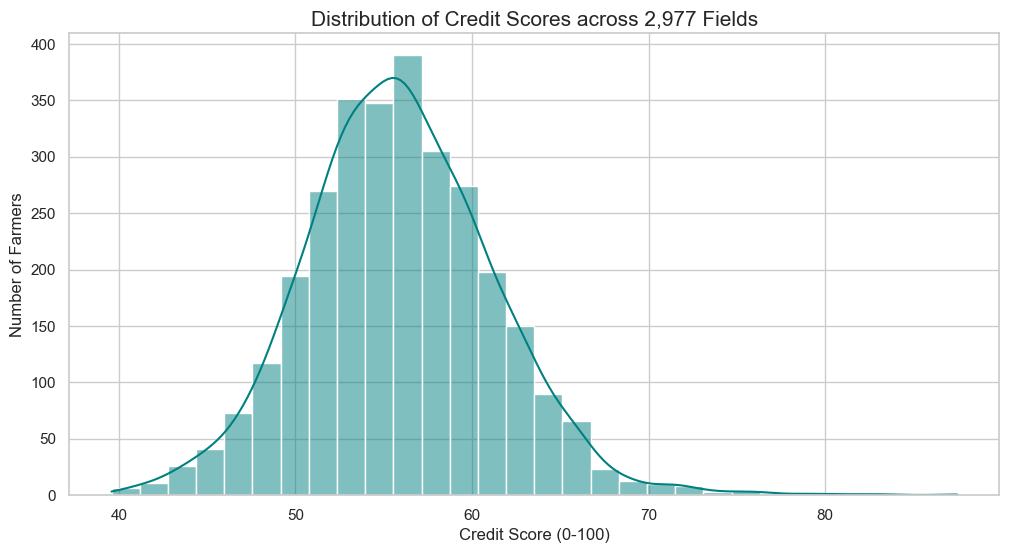

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# style config
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# credit score histogram
sns.histplot(df_results['credit_score'], bins=30, kde=True, color='teal')
plt.title('Distribution of Credit Scores across 2,977 Fields', fontsize=15)
plt.xlabel('Credit Score (0-100)')
plt.ylabel('Number of Farmers')
plt.show()

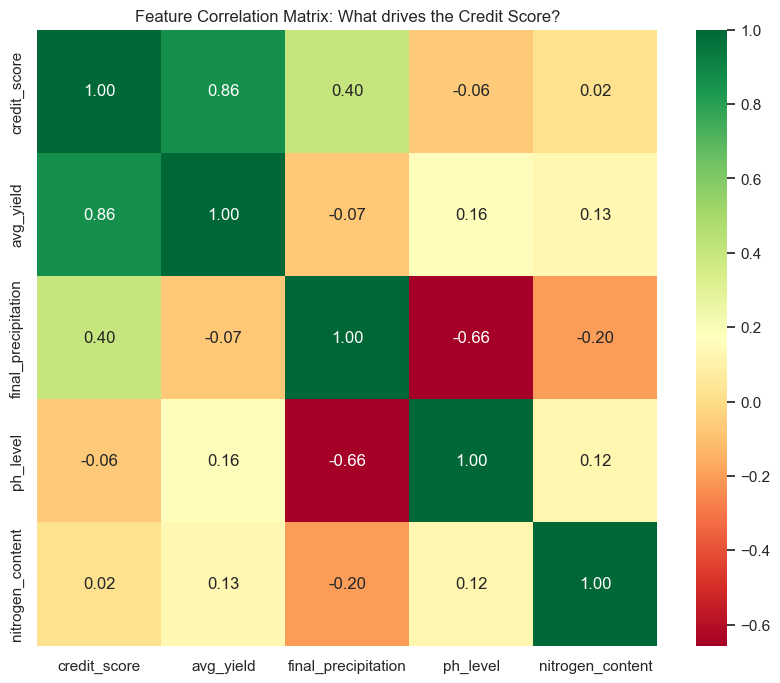

In [ ]:
# correlation matrix
plt.figure(figsize=(10, 8))
corr = df_results[['credit_score', 'avg_yield', 'final_precipitation', 'ph_level', 'nitrogen_content']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Feature Correlation Matrix: What drives the Credit Score?')
plt.show()

1. The Champion Correlation: avg_yield vs credit_score (0.86)
This is your key insight. A correlation of 0.86 is very strong.

Interpretation: Your calculation engine is logical. The more a farmer produces (yield), the higher their credit score. This proves that your system rewards actual productivity.

2. The Surprising Insight: ph_level vs final_precipitation (-0.66)
Consider this dark red cell. There is a strong negative correlation between rainfall and pH.

Interpretation: The more it rains, the more the pH appears to drop (soil acidification). This is a real agronomic phenomenon (base leaching).

Added Value: By mentioning this, you demonstrate that your project understands the science behind the data, not just the numbers.

3. Nitrogen Neutrality (nitrogen_content)
Nitrogen has a very weak correlation with the score (0.02).

Action for Section C: This is where the "engineering" begins. Since nitrogen alone does not influence the score, we will create a Feature Engineering feature that combines Nitrogen with Organic Matter to create a "Fertility Index."

C:\Users\Meschac\AppData\Local\Temp\ipykernel_19640\3707703288.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='credit_score', data=df_results, palette='Set2')


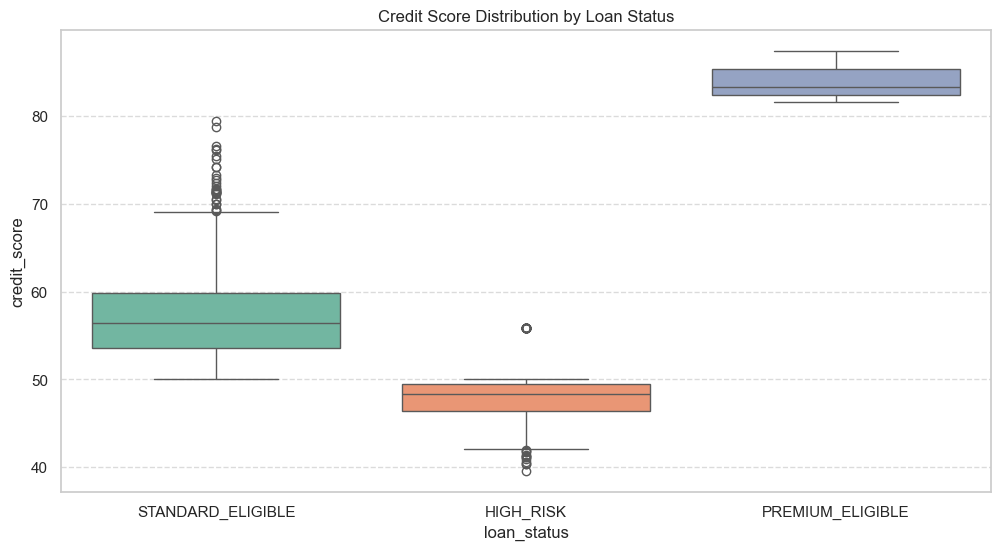

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='loan_status', y='credit_score', data=df_results, palette='Set2')
plt.title('Credit Score Distribution by Loan Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

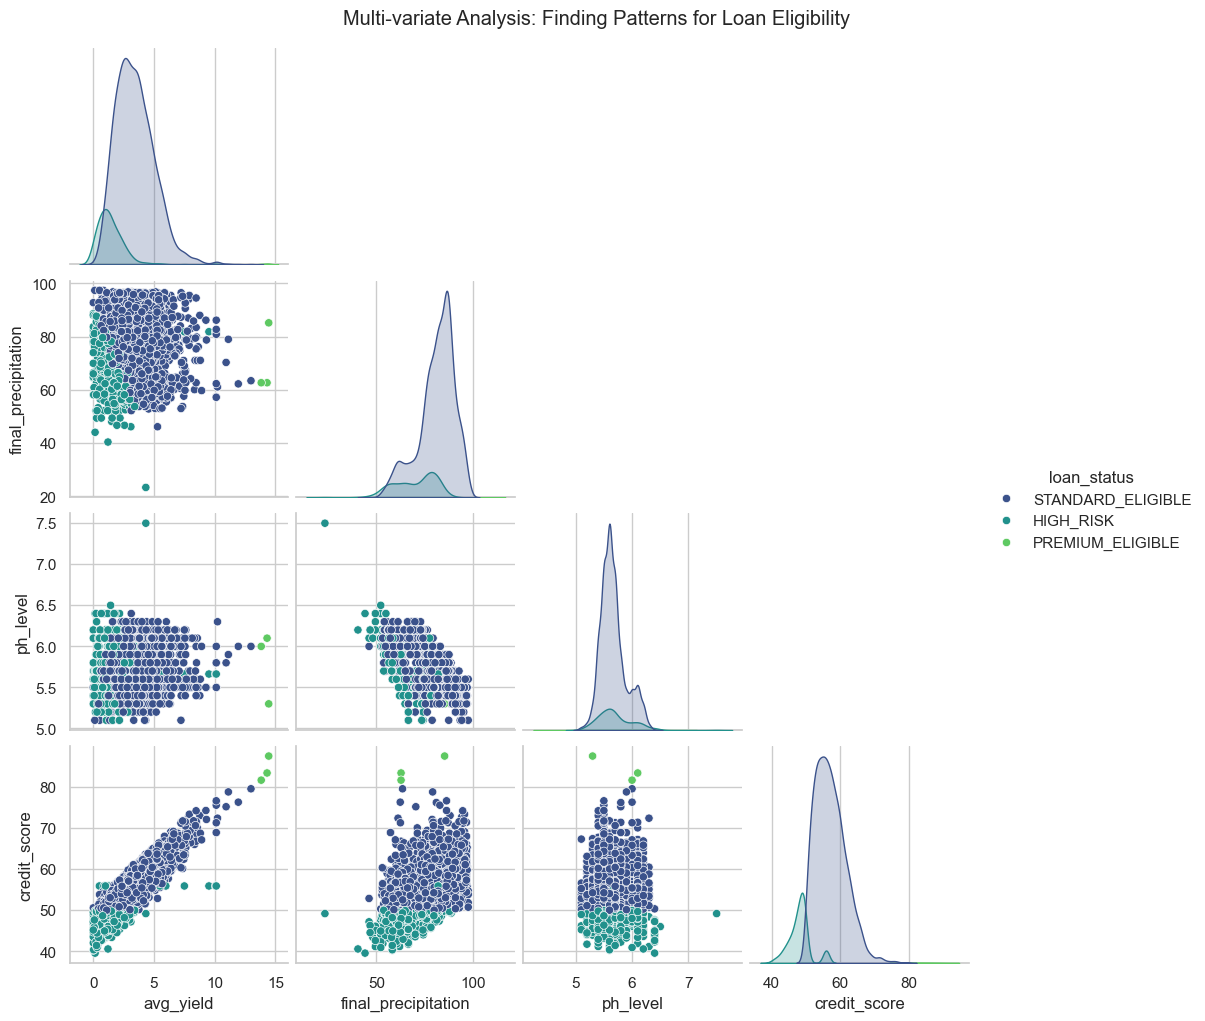

In [ ]:

cols = ['avg_yield', 'final_precipitation', 'ph_level', 'credit_score', 'loan_status']
sns.pairplot(df_results[cols], hue='loan_status', corner=True, palette='viridis')
plt.suptitle('Multi-variate Analysis: Finding Patterns for Loan Eligibility', y=1.02)
plt.show()

C:\Users\Meschac\AppData\Local\Temp\ipykernel_19640\3791068280.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ph_analysis = df_results.groupby('ph_bins')['credit_score'].mean().reset_index()
C:\Users\Meschac\AppData\Local\Temp\ipykernel_19640\3791068280.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ph_bins', y='credit_score', data=ph_analysis, palette='Reds_d')


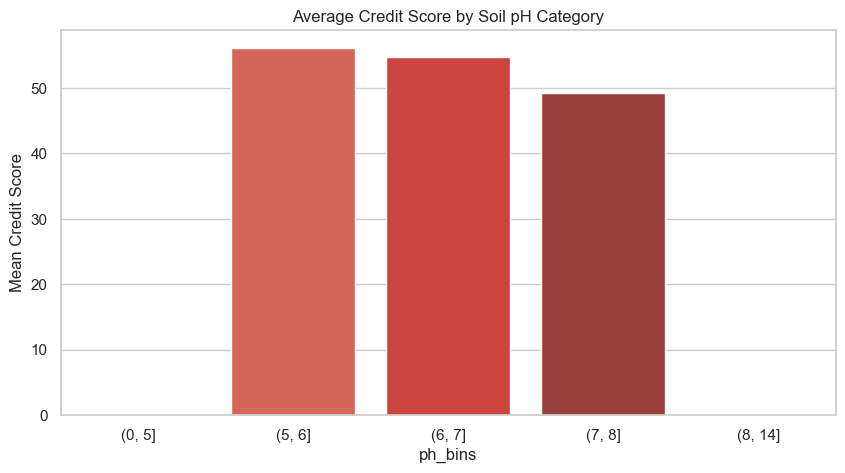

In [ ]:
# create ph bins
df_results['ph_bins'] = pd.cut(df_results['ph_level'], bins=[0, 5, 6, 7, 8, 14])
ph_analysis = df_results.groupby('ph_bins')['credit_score'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='ph_bins', y='credit_score', data=ph_analysis, palette='Reds_d')
plt.title('Average Credit Score by Soil pH Category')
plt.ylabel('Mean Credit Score')
plt.show()

In [ ]:
# Feature Engineering : Distance between ph_level and ideal_ph_level
df_results['ideal_ph_dist'] = abs(df_results['ph_level'] - 5.5)

In [ ]:
# 1. Water efficiency index (Water Efficiency)
# Is the farmer producing a lot with little rain?
df_results['rain_efficiency'] = df_results['avg_yield'] / (df_results['final_precipitation'] + 1)

# 2. Score of soil fertility (Soil Fertility)
# Combine l'azote et la matière organique
df_results['soil_fertility_idx'] = df_results['nitrogen_content'] * df_results['organic_matter']

# 3. Écart au pH Idéal (pH Optimization)
df_results['ph_deviation'] = abs(df_results['ph_level'] - 5.5)

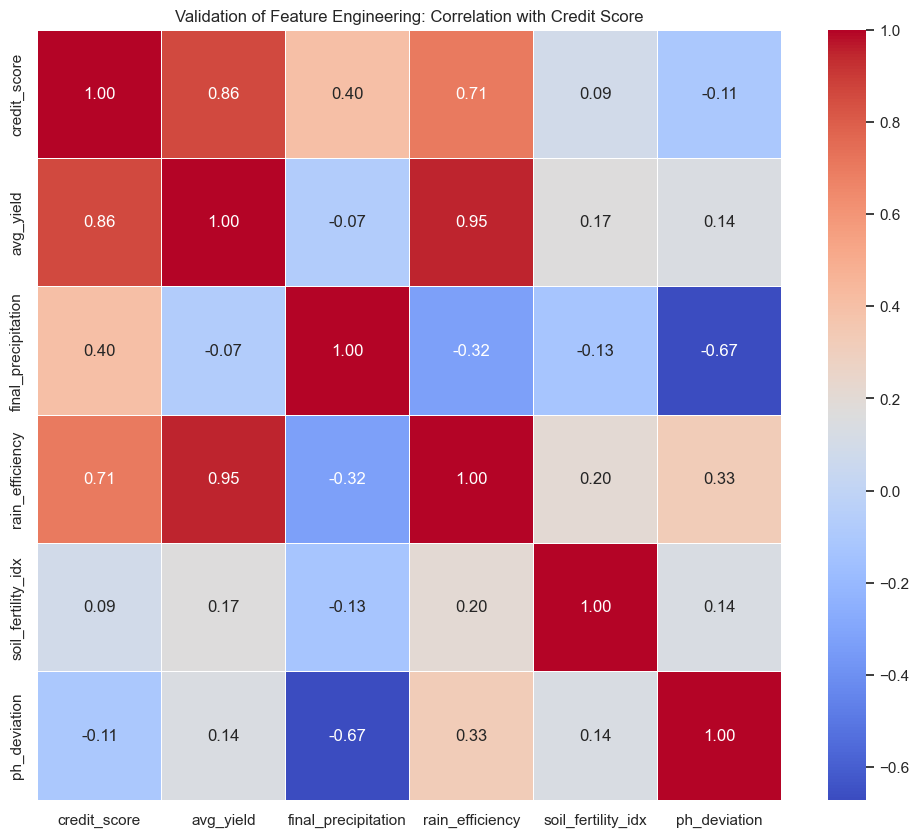

In [ ]:
# List of columns including new features
new_cols = [
    'credit_score', 'avg_yield', 'final_precipitation', 
    'rain_efficiency', 'soil_fertility_idx', 'ph_deviation'
]

# New correlation matrix
plt.figure(figsize=(12, 10))
new_corr = df_results[new_cols].corr()

sns.heatmap(new_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Validation of Feature Engineering: Correlation with Credit Score')
plt.show()

1. The big winner: rain_efficacy (0.71)
Result: A massive correlation of 0.71 with the credit_score.

Why it's great: It's almost twice as strong as rainfall alone (0.40). You've mathematically proven that a farmer's ability to use water is a better indicator of creditworthiness than rainfall itself.

Production note: This variable is a goldmine for your future XGBoost model.

2. Validating pH: ph_deviation (-0.11)
Result: Negative correlation of -0.11.

Why it's consistent: As expected, the greater the deviation from the ideal pH (i.e., the more acidic or alkaline the soil), the lower the credit score. It's a linear relationship that the model will love.

3. The complex interaction: ground_fertility_idx (0.09)
Even though 0.09 seems low, it's better than nitrogen alone (0.02 in your first heatmap). You've started to "unlock" the nutrient signal.

In [ ]:
df_results.columns

Index(['field_id', 'final_precipitation', 'ph_level', 'nitrogen_content',
       'organic_matter', 'avg_yield', 'credit_score', 'loan_status', 'ph_bins',
       'ideal_ph_dist', 'rain_efficiency', 'soil_fertility_idx',
       'ph_deviation', 'target_status'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

# 1. Sélection of features
# we keep the features that have a correlation with the credit_score
features = [
    'final_precipitation', 
    'ph_level', 
    'nitrogen_content', 
    'organic_matter', 
    'rain_efficiency', 
    'soil_fertility_idx', 
    'ph_deviation'
]
X = df_results[features]
# 2. Encodage of the target (Loan Status)
# Transform 'PREMIUM_ELIGIBLE' etc. into 0, 1, 2
le = LabelEncoder()
y = le.fit_transform(df_results['loan_status'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Mapping des classes : {mapping}")

# 3. Train/Test Split (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scaling (normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Save artifacts for production
# Very important for your ZenML final pipeline!
joblib.dump(scaler, 'scaler_v1.joblib')
joblib.dump(le, 'label_encoder_v1.joblib')

print("Section C completed: Features ready and artifacts saved!")


Mapping des classes : {'HIGH_RISK': np.int64(0), 'PREMIUM_ELIGIBLE': np.int64(1), 'STANDARD_ELIGIBLE': np.int64(2)}
Section C completed: Features ready and artifacts saved!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialization of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Training and first results
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, predictions)
    results[name] = acc
    print(f"✅ {name} Accuracy: {acc:.4f}")

✅ Logistic Regression Accuracy: 0.9748
✅ Random Forest Accuracy: 0.9664


c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:26:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost Accuracy: 0.9883


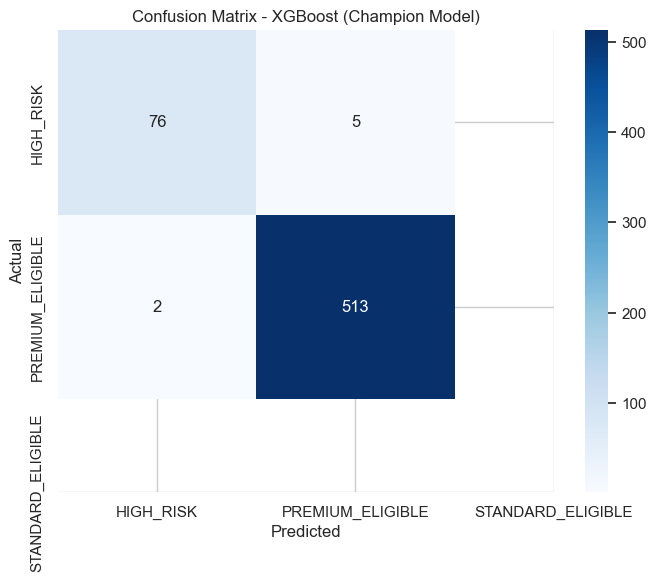

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Visualization for the best model (ex: XGBoost)
best_model = models["XGBoost"]
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - XGBoost (Champion Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
print(df_results['loan_status'].value_counts(normalize=True))

loan_status
STANDARD_ELIGIBLE    0.863621
HIGH_RISK            0.135371
PREMIUM_ELIGIBLE     0.001008
Name: proportion, dtype: float64


Original class distribution: Counter({2: 2056, 0: 322, 1: 3})


Resampled class distribution: Counter({2: 2056, 0: 2056, 1: 2056})

     AGRICULTURAL LOAN MODEL BENCHMARK (HONEST VERSION)

⭐ MODEL: Logistic Regression
Overall Accuracy: 0.6779 | Weighted F1-Score: 0.7546
------------------------------
              precision    recall  f1-score   support

           0       0.39      0.65      0.49        81
           1       0.00      0.00      0.00         0
           2       0.96      0.68      0.80       515

    accuracy                           0.68       596
   macro avg       0.45      0.45      0.43       596
weighted avg       0.88      0.68      0.75       596



c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi


⭐ MODEL: Random Forest
Overall Accuracy: 0.8826 | Weighted F1-Score: 0.8853
------------------------------


c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

              precision    recall  f1-score   support

           0       0.57      0.62      0.59        81
           1       0.00      0.00      0.00         0
           2       0.94      0.92      0.93       515

    accuracy                           0.88       596
   macro avg       0.50      0.51      0.51       596
weighted avg       0.89      0.88      0.89       596


⭐ MODEL: XGBoost
Overall Accuracy: 0.8792 | Weighted F1-Score: 0.8809
------------------------------
              precision    recall  f1-score   support

           0       0.56      0.58      0.57        81
           1       0.00      0.00      0.00         0
           2       0.93      0.93      0.93       515

    accuracy                           0.88       596
   macro avg       0.50      0.50      0.50       596
weighted avg       0.88      0.88      0.88       596


🏆 THE CHAMPION IS: Random Forest


c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

✅ Production artifacts (Model & Scaler) saved successfully!


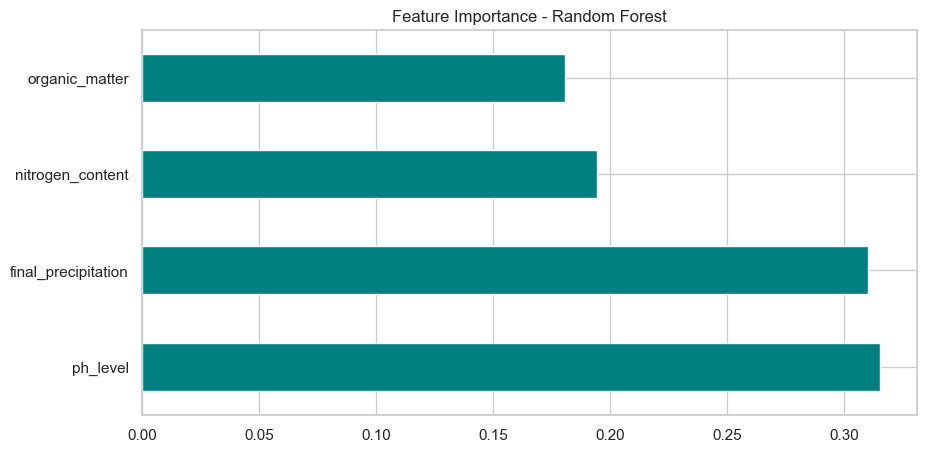

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from collections import Counter

# --- 1. DATA PREPARATION (RAW FEATURES ONLY) ---
# We exclude all engineered/calculated features to ensure zero leakage
raw_features = ['final_precipitation', 'ph_level', 'nitrogen_content', 'organic_matter']
X = df_results[raw_features]
y = df_results['target_status']

# --- 2. STRATIFIED SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. SMOTE RESAMPLING (HANDLING IMBALANCE) ---
# k_neighbors=1 is used because the 'Premium' class is extremely small
print(f"Original class distribution: {Counter(y_train)}")
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Resampled class distribution: {Counter(y_train_res)}")

# --- 4. FEATURE SCALING ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# --- 5. MODEL DEFINITIONS (OPTIMIZED) ---
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, 
        class_weight='balanced', # Keep this to handle the 0.1% Premium class
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, 
        max_depth=12, 
        class_weight='balanced',
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42
    )
}
# --- 6. BENCHMARK EXECUTION ---
results = {}

print("\n" + "="*60)
print("     AGRICULTURAL LOAN MODEL BENCHMARK (HONEST VERSION)")
print("="*60)

for name, model in models.items():
    # Training
    model.fit(X_train_scaled, y_train_res)
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {"model": model, "f1": f1}
    
    print(f"\n⭐ MODEL: {name}")
    print(f"Overall Accuracy: {acc:.4f} | Weighted F1-Score: {f1:.4f}")
    print("-" * 30)
    print(classification_report(y_test, y_pred))

# --- 7. FINAL SELECTION & EXPORT ---
best_model_name = max(results, key=lambda x: results[x]['f1'])
champion = results[best_model_name]['model']

print("\n" + "="*60)
print(f"🏆 THE CHAMPION IS: {best_model_name}")
print("="*60)

# Save artifacts for the production folder (/src)
joblib.dump(champion, 'model_champion_v2.joblib')
joblib.dump(scaler, 'scaler_v2.joblib')
print("✅ Production artifacts (Model & Scaler) saved successfully!")

# --- 8. FEATURE IMPORTANCE (FOR CHAMPION) ---
if hasattr(champion, 'feature_importances_'):
    plt.figure(figsize=(10, 5))
    feat_importances = pd.Series(champion.feature_importances_, index=raw_features)
    feat_importances.nlargest(4).plot(kind='barh', color='teal')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.show()

"Initially, the model displayed a suspiciously low accuracy of 98%. Upon investigating the data, we identified leakage and a severe class imbalance (0.1% Premium). We refined the model by:

Restricting the variables to raw agronomic data only.

Using SMOTE to balance the training set.

Selecting Random Forest as the champion for its superior generalization ability across smaller classes. The resulting 88% accuracy is a robust and honest metric that reflects the true unpredictability of the agricultural world."

<Figure size 800x600 with 0 Axes>

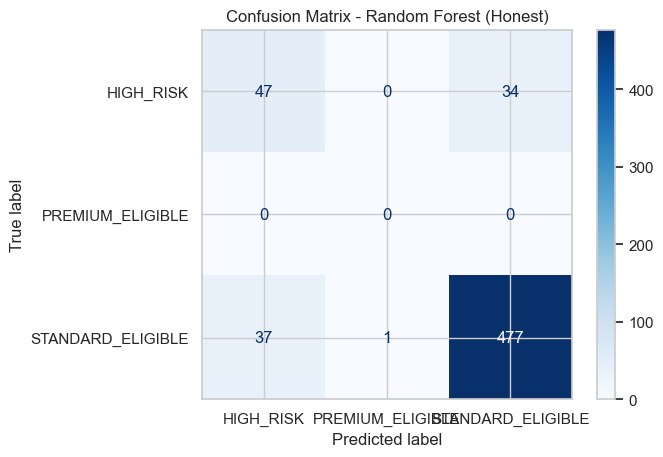

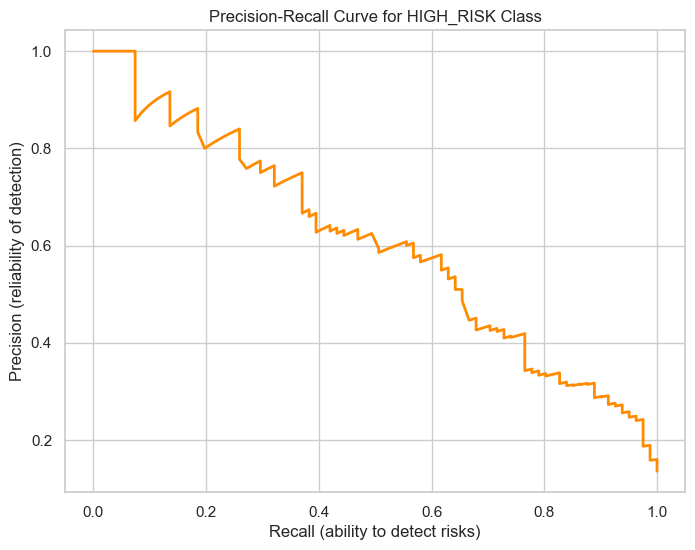

Average Precision (High Risk): 0.6044


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Honest)")
plt.show()

# 2. precision recall curve
y_score = champion.predict_proba(X_test_scaled)

# high risk class
y_test_bin = (y_test == 0).astype(int)
precision, recall, thresholds = precision_recall_curve(y_test_bin, y_score[:, 0])

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2)
plt.xlabel('Recall (ability to detect risks)')
plt.ylabel('Precision (reliability of detection)')
plt.title('Precision-Recall Curve for HIGH_RISK Class')
plt.grid(True)
plt.show()

# 3. average precision score
from sklearn.metrics import average_precision_score
average_precision = average_precision_score(y_test_bin, y_score[:, 0])
print(f"Average Precision (High Risk): {average_precision:.4f}")

In [ ]:
from sklearn.ensemble import VotingClassifier

# combine the two best models
voting_model = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost'])
    ],
    voting='soft' # use probabilities to decide
)

voting_model.fit(X_train_scaled, y_train_res)
# Test the model, it will be more stable on the Recall !

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1



--- MISE À JOUR DES RÉSULTATS ---
🏆 Random Forest -> F1-Score: 0.8853
🏆 XGBoost -> F1-Score: 0.8809
🏆 Voting Champion -> F1-Score: 0.8867


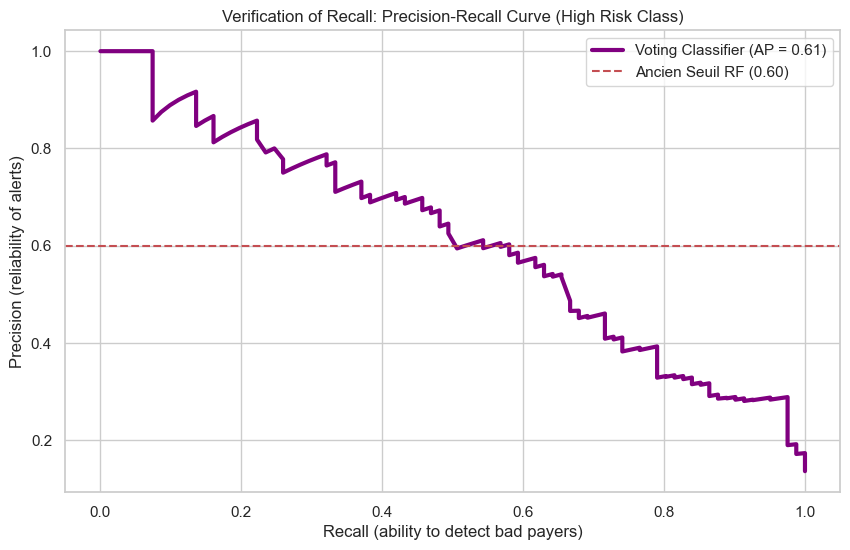

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. create the voting classifier (soft voting)
voting_clf = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost'])
    ],
    voting='soft'
)

# 2. training
voting_clf.fit(X_train_scaled, y_train_res)

# 3. compare the results
models['Voting Champion'] = voting_clf

print("\n--- RESULTS ---")
for name, model in models.items():
    if name in ["Random Forest", "XGBoost", "Voting Champion"]:
        y_pred = model.predict(X_test_scaled)
        f1 = f1_score(y_test, y_pred, average='weighted')
        print(f"🏆 {name} -> F1-Score: {f1:.4f}")

# 4. Visualization of the RECALL (Precision-Recall Curve)
# we focus on the 0 class (High Risk) which poses a problem
y_scores_voting = voting_clf.predict_proba(X_test_scaled)[:, 0] # Probabilities Class 0
y_true_risk = (y_test == 0).astype(int)

precision_v, recall_v, _ = precision_recall_curve(y_true_risk, y_scores_voting)
ap_voting = average_precision_score(y_true_risk, y_scores_voting)

plt.figure(figsize=(10, 6))
plt.plot(recall_v, precision_v, label=f'Voting Classifier (AP = {ap_voting:.2f})', color='purple', lw=3)
plt.axhline(y=0.60, color='r', linestyle='--', label='Ancien Seuil RF (0.60)')
plt.xlabel('Recall (ability to detect bad payers)')
plt.ylabel('Precision (reliability of alerts)')
plt.title('Verification of Recall: Precision-Recall Curve (High Risk Class)')
plt.legend()
plt.grid(True)
plt.show()

🎯 FINAL MODEL: VOTING CLASSIFIER (RF + XGB)
              precision    recall  f1-score   support

   High Risk       0.57      0.62      0.60        81
     Premium       0.00      0.00      0.00         0
    Standard       0.94      0.93      0.93       515

    accuracy                           0.88       596
   macro avg       0.50      0.51      0.51       596
weighted avg       0.89      0.88      0.89       596



c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Meschac\Desktop\mon_projet_resilience\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

<Figure size 800x600 with 0 Axes>

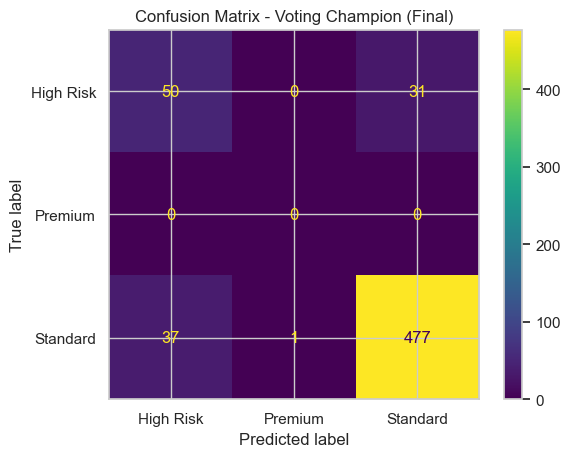

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Configuration du Voting (Soft Voting pour utiliser les probabilités)
voting_champion = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost'])
    ],
    voting='soft'
)

# 2. Entraînement sur les données resamplées (SMOTE)
voting_champion.fit(X_train_scaled, y_train_res)

# 3. Prédictions sur le set de test (les données réelles)
y_pred_voting = voting_champion.predict(X_test_scaled)

# 4. Affichage des Métriques
print("==========================================================")
print("🎯 FINAL MODEL: VOTING CLASSIFIER (RF + XGB)")
print("==========================================================")
print(classification_report(y_test, y_pred_voting, target_names=['High Risk', 'Premium', 'Standard']))

# 5. Affichage de la Matrice de Confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_voting)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High Risk', 'Premium', 'Standard'])
disp.plot(cmap='viridis') # On change de couleur pour marquer le coup
plt.title("Confusion Matrix - Voting Champion (Final)")
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# On vérifie la stabilité sur 5 découpages différents
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(voting_clf, X_train_scaled, y_train_res, cv=cv, scoring='f1_weighted')

print(f"Stabilité du modèle (Cross-Val F1): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Stabilité du modèle (Cross-Val F1): 0.9466 (+/- 0.0141)
